In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

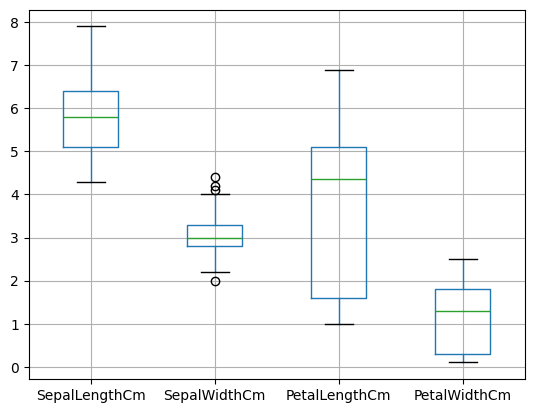

In [2]:
data = pd.read_csv('Iris.csv')
data = data.drop('Id', axis=1)   # remove useless column

data.boxplot()
plt.show()

**KNN**

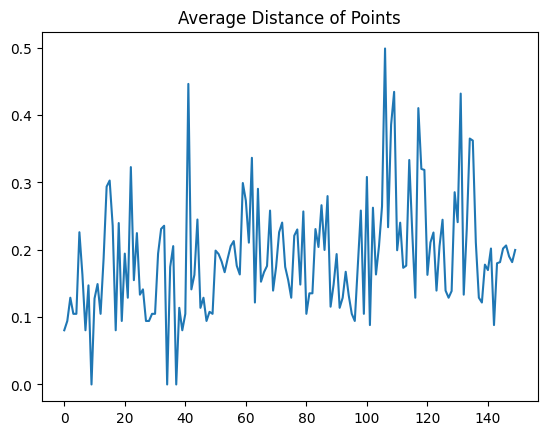

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm          Species
15             5.7           4.4            1.5           0.4      Iris-setosa
22             4.6           3.6            1.0           0.2      Iris-setosa
41             4.5           2.3            1.3           0.3      Iris-setosa
62             6.0           2.2            4.0           1.0  Iris-versicolor
100            6.3           3.3            6.0           2.5   Iris-virginica
106            4.9           2.5            4.5           1.7   Iris-virginica
108            6.7           2.5            5.8           1.8   Iris-virginica
109            7.2           3.6            6.1           2.5   Iris-virginica
114            5.8           2.8            5.1           2.4   Iris-virginica
117            7.7           3.8            6.7           2.2   Iris-virginica
118            7.7           2.6            6.9           2.3   Iris-virginica
119            6.0           2.2            5.0     

In [6]:
#Prepare features for KNN
X = data.drop('Species', axis=1).values

#Apply KNN to find outliers
knn = NearestNeighbors(n_neighbors=3)
knn.fit(X)

#Calculate average distance to neighbors
distances, _ = knn.kneighbors(X)
avg_dist = distances.mean(axis=1)

#Plot average distance to identify outliers
plt.plot(avg_dist)
plt.title("Average Distance of Points")
plt.show()

#Identify outliers based on average distance
outliers_knn = data[avg_dist > 0.3]   # threshold chosen from graph
print(outliers_knn)

**DBSCAN**

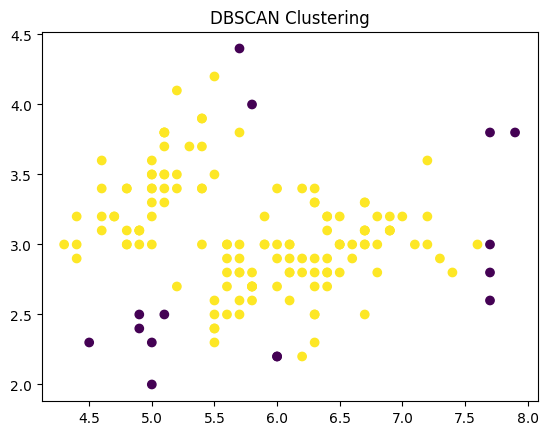

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm          Species
14             5.8           4.0            1.2           0.2      Iris-setosa
15             5.7           4.4            1.5           0.4      Iris-setosa
41             4.5           2.3            1.3           0.3      Iris-setosa
57             4.9           2.4            3.3           1.0  Iris-versicolor
60             5.0           2.0            3.5           1.0  Iris-versicolor
62             6.0           2.2            4.0           1.0  Iris-versicolor
93             5.0           2.3            3.3           1.0  Iris-versicolor
98             5.1           2.5            3.0           1.1  Iris-versicolor
106            4.9           2.5            4.5           1.7   Iris-virginica
117            7.7           3.8            6.7           2.2   Iris-virginica
118            7.7           2.6            6.9           2.3   Iris-virginica
119            6.0           2.2            5.0     

In [4]:
#Select features
df = data[["SepalLengthCm", "SepalWidthCm"]]

#Apply DBSCAN
db = DBSCAN(eps=0.4, min_samples=10)
labels = db.fit_predict(df)

#Plot DBSCAN results
plt.scatter(df["SepalLengthCm"], df["SepalWidthCm"], c=labels)
plt.title("DBSCAN Clustering")
plt.show()

#Identify outliers based on DBSCAN
outliers_dbscan = data[labels == -1]
print(outliers_dbscan)